# EduPredict-XAI

## Step 18 — Explainable AI Analysis

### Objective

Explain how the TabPFN model makes student performance predictions.

### Main Model
TabPFN

### XAI Technique
SHAP (SHapley Additive exPlanations)

### Target
final_exam_score

In [3]:
# Import Libraries
import os
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

from sklearn.model_selection import train_test_split

print("=" * 60)
print("LIBRARIES IMPORTED")
print("=" * 60)

print("Python:", sys.version.split()[0])
print("SHAP version:", shap.__version__)

print("\nAll required libraries imported successfully!")

LIBRARIES IMPORTED
Python: 3.10.9
SHAP version: 0.49.1

All required libraries imported successfully!


In [ ]:
# Find Project Root

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print("=" * 60)
print("PROJECT ROOT")
print("=" * 60)

print(PROJECT_ROOT)

if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError(
        "Project root could not be identified."
    )

print("\nProject root verified successfully!")

PROJECT ROOT
d:\MCA Sem 3\RP\EduPredict-XAI

Project root verified successfully! ✅


In [5]:
# Define Project Paths

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "student_performance_feature_engineered.csv"
)

RESULTS_PATH = (
    PROJECT_ROOT
    / "results"
)

XAI_RESULTS_PATH = (
    RESULTS_PATH
    / "xai"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
)

print("=" * 60)
print("PROJECT PATHS")
print("=" * 60)

print("\nData:")
print(DATA_PATH)

print("\nResults:")
print(RESULTS_PATH)

print("\nXAI Results:")
print(XAI_RESULTS_PATH)

print("\nModels:")
print(MODEL_PATH)

PROJECT PATHS

Data:
d:\MCA Sem 3\RP\EduPredict-XAI\data\processed\student_performance_feature_engineered.csv

Results:
d:\MCA Sem 3\RP\EduPredict-XAI\results

XAI Results:
d:\MCA Sem 3\RP\EduPredict-XAI\results\xai

Models:
d:\MCA Sem 3\RP\EduPredict-XAI\models


In [7]:
# Verify Required Files

required_files = {
    "Feature-engineered dataset":
        DATA_PATH,

    "Model comparison":
        RESULTS_PATH / "final_model_comparison.csv",

    "Model ranking":
        RESULTS_PATH / "model_ranking.csv",

    "TabPFN predictions":
        RESULTS_PATH / "tabpfn_predictions_with_error.csv"
}

print("=" * 60)
print("VERIFYING STEP 17 FILES")
print("=" * 60)

for name, path in required_files.items():

    status = "FOUND" if path.exists() else "MISSING"

    print(f"\n{name}:")
    print(path)
    print(status)

    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}"
        )

print("\nAll Step 17 files verified successfully!")

VERIFYING STEP 17 FILES

Feature-engineered dataset:
d:\MCA Sem 3\RP\EduPredict-XAI\data\processed\student_performance_feature_engineered.csv
FOUND

Model comparison:
d:\MCA Sem 3\RP\EduPredict-XAI\results\final_model_comparison.csv
FOUND

Model ranking:
d:\MCA Sem 3\RP\EduPredict-XAI\results\model_ranking.csv
FOUND

TabPFN predictions:
d:\MCA Sem 3\RP\EduPredict-XAI\results\tabpfn_predictions_with_error.csv
FOUND

All Step 17 files verified successfully!


In [8]:
# Load Feature-Engineered Dataset

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("FEATURE-ENGINEERED DATASET")
print("=" * 60)

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

FEATURE-ENGINEERED DATASET

Shape: (1000, 10)

Columns:
['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'previous_grade', 'final_exam_score']


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3
3,Male,2.6,77.5,8.0,High School,Yes,Yes,No,85.1,83.8
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3


In [9]:
# Define Target and Features

TARGET = "final_exam_score"

if TARGET not in df.columns:
    raise KeyError(
        f"Target '{TARGET}' not found in dataset."
    )

X = df.drop(
    columns=[TARGET]
).copy()

y = df[TARGET].copy()

print("=" * 60)
print("TARGET AND FEATURES")
print("=" * 60)

print("\nTarget:")
print(TARGET)

print("\nFeatures:")
for i, feature in enumerate(
    X.columns,
    start=1
):
    print(f"{i}. {feature}")

print("\nNumber of features:", X.shape[1])
print("Number of records:", X.shape[0])

TARGET AND FEATURES

Target:
final_exam_score

Features:
1. gender
2. study_time_hours
3. attendance_percent
4. sleep_hours
5. parental_education
6. internet_access
7. extracurricular_activities
8. part_time_job
9. previous_grade

Number of features: 9
Number of records: 1000


In [10]:
# Recreate the Same Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("\nTraining features:", X_train.shape)
print("Testing features :", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target :", y_test.shape)

TRAIN / TEST SPLIT

Training features: (800, 9)
Testing features : (200, 9)

Training target: (800,)
Testing target : (200,)


In [11]:
# Load Fitted TabPFN Model

TABPFN_MODEL_PATH = (
    MODEL_PATH
    / "tabpfn_fitted_model.pkl"
)

print("=" * 60)
print("LOADING TABPFN MODEL")
print("=" * 60)

print("\nModel path:")
print(TABPFN_MODEL_PATH)

if not TABPFN_MODEL_PATH.exists():
    raise FileNotFoundError(
        "tabpfn_fitted_model.pkl was not found.\n"
        "Please verify that Step 16 saved the fitted model."
    )

with open(
    TABPFN_MODEL_PATH,
    "rb"
) as file:

    tabpfn_model = pickle.load(file)

print("\nTabPFN model loaded successfully!")
print("Model type:")
print(type(tabpfn_model))

LOADING TABPFN MODEL

Model path:
d:\MCA Sem 3\RP\EduPredict-XAI\models\tabpfn_fitted_model.pkl

TabPFN model loaded successfully!
Model type:
<class 'tabpfn.regressor.TabPFNRegressor'>


In [12]:
# Verify TabPFN Model

print("=" * 60)
print("TABPFN MODEL VERIFICATION")
print("=" * 60)

test_input = X_test.iloc[:3].copy()

test_predictions = tabpfn_model.predict(
    test_input
)

print("\nTest input shape:")
print(test_input.shape)

print("\nPredictions:")
print(test_predictions)

if len(test_predictions) != 3:
    raise ValueError(
        "TabPFN prediction verification failed."
    )

print("\nTabPFN model is working correctly!")

TABPFN MODEL VERIFICATION


TabPFN inference: 100%|██████████| 8/8 [00:23<00:00,  2.89s/estimator]


Test input shape:
(3, 9)

Predictions:
[78.14627 72.48883 73.4301 ]

TabPFN model is working correctly!


In [13]:
# Load Step 17 TabPFN Predictions

PREDICTIONS_PATH = (
    RESULTS_PATH
    / "tabpfn_predictions_with_error.csv"
)

predictions_df = pd.read_csv(
    PREDICTIONS_PATH
)

print("=" * 60)
print("STEP 17 TABPFN PREDICTIONS")
print("=" * 60)

print("\nShape:")
print(predictions_df.shape)

print("\nColumns:")
print(predictions_df.columns.tolist())

display(
    predictions_df.head()
)

STEP 17 TABPFN PREDICTIONS

Shape:
(200, 4)

Columns:
['Actual', 'Predicted', 'Absolute_Error', 'Error']


,Actual,Predicted,Absolute_Error,Error
0,71.8,78.146300,6.346300,-6.346300
1,66.6,72.488830,5.888830,-5.888830
2,62.9,73.430115,10.530115,-10.530115
3,95.2,92.228600,2.971400,2.971400
4,90.2,89.471405,0.728595,0.728595


In [16]:
# Verify Step 17 Performance

comparison_path = (
    RESULTS_PATH
    / "final_model_comparison.csv"
)

comparison_df = pd.read_csv(
    comparison_path
)

print("=" * 60)
print("STEP 17 MODEL COMPARISON")
print("=" * 60)

display(comparison_df)

# Verify TabPFN exists in comparison

if "TabPFN" not in comparison_df.to_string():
    print(
        "Warning: TabPFN name was not found exactly "
        "in the comparison table."
    )
else:
    print(
        "\nTabPFN is present in the model comparison."
    )

STEP 17 MODEL COMPARISON


,Model,MAE,RMSE,R2
0,CatBoost,5.3463,6.8105,0.5691
1,XGBoost,5.7965,7.3319,0.5006
2,LightGBM,6.0824,7.5547,0.4698
3,TabPFN,4.9842,6.4538,0.6130



TabPFN is present in the model comparison.


In [17]:
# CELL 13 — Create SHAP Background Dataset

SHAP_BACKGROUND_SIZE = min(
    20,
    len(X_train)
)

shap_background = X_train.sample(
    n=SHAP_BACKGROUND_SIZE,
    random_state=42
).copy()

print("=" * 60)
print("SHAP BACKGROUND DATA")
print("=" * 60)

print("\nBackground records:",
      len(shap_background))

print("Features:",
      shap_background.shape[1])

display(
    shap_background.head()
)

SHAP BACKGROUND DATA

Background records: 20
Features: 9


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade
726,Male,4.8,85.4,6.4,High School,Yes,Yes,No,69.0
138,Male,2.4,81.3,7.9,High School,Yes,Yes,No,74.6
266,Female,3.1,86.9,7.4,Masters,Yes,Yes,Yes,88.5
765,Male,0.5,100.0,6.4,Masters,Yes,Yes,No,65.0
798,Male,2.0,62.9,5.9,Bachelors,Yes,Yes,Yes,53.5


In [18]:
# TabPFN Prediction Function for SHAP

def tabpfn_predict_for_shap(data):

    if isinstance(
        data,
        pd.DataFrame
    ):
        data_df = data.copy()

    else:
        data_df = pd.DataFrame(
            data,
            columns=X_train.columns
        )

    predictions = tabpfn_model.predict(
        data_df
    )

    return np.asarray(
        predictions,
        dtype=float
    )

print(
    "SHAP prediction function created successfully!"
)

SHAP prediction function created successfully!


In [19]:
# Test SHAP Prediction Function

shap_test_input = X_test.iloc[:3].copy()

shap_test_predictions = (
    tabpfn_predict_for_shap(
        shap_test_input
    )
)

print("=" * 60)
print("TESTING SHAP PREDICTION FUNCTION")
print("=" * 60)

print("\nInput:")
print(shap_test_input.shape)

print("\nPredictions:")
print(shap_test_predictions)

if len(shap_test_predictions) != 3:
    raise ValueError(
        "SHAP prediction function test failed."
    )

print(
    "\nSHAP prediction function works correctly!"
)

TabPFN inference: 100%|██████████| 8/8 [00:20<00:00,  2.53s/estimator]

TESTING SHAP PREDICTION FUNCTION

Input:
(3, 9)

Predictions:
[78.14627075 72.48883057 73.43009949]

SHAP prediction function works correctly!


In [21]:
# Create SHAP Explainer

print("=" * 60)
print("CREATING SHAP EXPLAINER")
print("=" * 60)

explainer = shap.KernelExplainer(
    tabpfn_predict_for_shap,
    shap_background.to_numpy()
)

print(
    "\nSHAP KernelExplainer created successfully!"
)

CREATING SHAP EXPLAINER


TabPFN inference: 100%|██████████| 8/8 [00:17<00:00,  2.14s/estimator]


SHAP KernelExplainer created successfully!


In [22]:
# Select Students for SHAP Analysis

SHAP_SAMPLE_SIZE = min(
    10,
    len(X_test)
)

shap_sample = X_test.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
).copy()

shap_actual = y_test.loc[
    shap_sample.index
]

print("=" * 60)
print("SHAP ANALYSIS SAMPLE")
print("=" * 60)

print("\nStudents selected:",
      len(shap_sample))

print("Features:",
      shap_sample.shape[1])

display(
    shap_sample
)

SHAP ANALYSIS SAMPLE

Students selected: 10
Features: 9


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade
436,Female,6.9,82.8,6.7,High School,Yes,Yes,Yes,63.1
899,Male,1.5,89.6,8.6,High School,Yes,No,No,51.3
346,Male,4.1,84.8,7.5,High School,Yes,No,No,76.6
60,Male,4.0,79.7,7.2,Masters,Yes,Yes,No,67.4
867,Female,4.1,84.9,8.1,Masters,Yes,Yes,No,71.7
432,Male,3.6,82.9,7.3,High School,Yes,No,Yes,76.0
543,Female,3.4,100.0,8.0,High School,Yes,No,No,84.2
361,Male,2.4,90.0,5.4,Masters,Yes,No,Yes,100.0
486,Male,1.4,81.9,4.3,High School,Yes,No,No,69.6
277,Female,2.7,78.9,5.7,High School,Yes,No,Yes,78.3


In [24]:
# Calculate SHAP Values

print("=" * 60)
print("CALCULATING SHAP VALUES")
print("=" * 60)

print("\nModel: TabPFN")
print("XAI: SHAP")
print("Students:", len(shap_sample))
print("Background:", len(shap_background))
print("Features:", shap_sample.shape[1])

print("\nSHAP calculation started...")
print("Please wait and do not restart the kernel.")

shap_values = explainer.shap_values(
    shap_sample.to_numpy(),
    nsamples=100,
    silent=False
)

print(
    "\nSHAP calculation completed successfully!"
)

CALCULATING SHAP VALUES

Model: TabPFN
XAI: SHAP
Students: 10
Background: 20
Features: 9

SHAP calculation started...
Please wait and do not restart the kernel.


100%|██████████| 10/10 [08:51<00:00, 53.17s/it]


SHAP calculation completed successfully!


In [25]:
# Validate SHAP Values

if isinstance(
    shap_values,
    list
):
    shap_array = np.asarray(
        shap_values[0]
    )
else:
    shap_array = np.asarray(
        shap_values
    )

print("=" * 60)
print("SHAP OUTPUT VALIDATION")
print("=" * 60)

print("\nSHAP shape:")
print(shap_array.shape)

print("\nExpected shape:")
print(
    (
        len(shap_sample),
        X_test.shape[1]
    )
)

if shap_array.shape != (
    len(shap_sample),
    X_test.shape[1]
):
    raise ValueError(
        "SHAP output shape does not match "
        "the student-feature dimensions."
    )

print(
    "\nSHAP values validated successfully!"
)

SHAP OUTPUT VALIDATION

SHAP shape:
(10, 9)

Expected shape:
(10, 9)

SHAP values validated successfully!


In [26]:
# Create SHAP DataFrame

shap_values_df = pd.DataFrame(
    shap_array,
    columns=X_test.columns,
    index=shap_sample.index
)

print("=" * 60)
print("SHAP VALUES TABLE")
print("=" * 60)

display(
    shap_values_df
)

SHAP VALUES TABLE


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade
436,-0.033511,11.591233,-0.418452,0.257002,-0.134587,0.905685,0.200767,-1.846615,-2.213719
899,-0.033061,-10.236993,1.563586,2.059126,-0.269170,1.003193,-0.505370,1.285610,-7.497382
346,-0.017082,1.380479,0.079701,1.040761,-0.262211,0.891835,-0.510377,1.179591,1.927946
60,-0.000046,0.758730,-1.644969,0.781564,0.248636,0.952677,0.257176,1.251080,-1.311834
867,-0.098878,1.364775,0.071324,1.646056,0.256397,0.941649,0.204546,1.112227,0.212773
432,-0.039735,-1.121535,-0.614610,0.885353,-0.266843,0.945622,-0.508149,-2.165764,1.745349
543,0.000720,-1.182445,4.941797,1.406338,-0.138659,0.849624,-0.484170,1.042034,4.272397
361,-0.046096,-5.508815,1.584010,-1.008883,0.183953,0.911271,-0.496811,-1.925920,11.036213
486,-0.001958,-10.852214,-0.971068,-1.718674,-0.291524,0.959563,-0.460125,1.331557,-0.723773
277,0.091363,-5.548509,-1.958968,-0.751090,-0.242286,0.964152,-0.492548,-2.165011,2.537987


In [27]:
# Global SHAP Feature Importance

global_shap_importance = (
    shap_values_df
    .abs()
    .mean()
    .sort_values(
        ascending=False
    )
)

global_shap_df = pd.DataFrame({
    "Feature":
        global_shap_importance.index,

    "Mean_Absolute_SHAP":
        global_shap_importance.values
})

print("=" * 60)
print("GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 60)

display(
    global_shap_df
)

GLOBAL SHAP FEATURE IMPORTANCE


,Feature,Mean_Absolute_SHAP
0,study_time_hours,4.954573
1,previous_grade,3.347937
2,part_time_job,1.530541
3,attendance_percent,1.384848
4,sleep_hours,1.155485
5,internet_access,0.932527
6,extracurricular_activities,0.412004
7,parental_education,0.229427
8,gender,0.036245


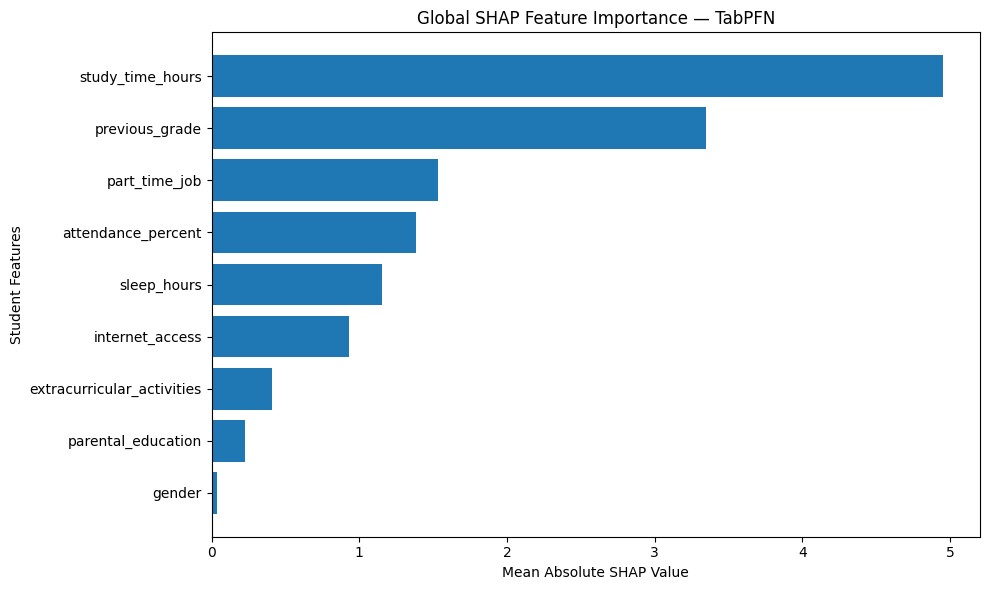

In [28]:
# Global SHAP Importance Graph

plt.figure(figsize=(10, 6))

plt.barh(
    global_shap_df["Feature"],
    global_shap_df["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Student Features"
)

plt.title(
    "Global SHAP Feature Importance — TabPFN"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

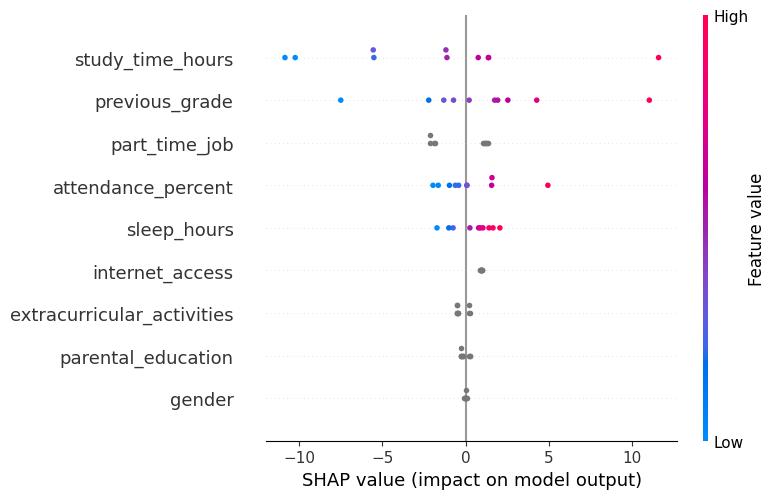

In [29]:
# SHAP Summary Plot

shap.summary_plot(
    shap_array,
    shap_sample,
    feature_names=X_test.columns,
    show=True
)

In [30]:
# Save SHAP Results

XAI_RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

GLOBAL_SHAP_PATH = (
    XAI_RESULTS_PATH
    / "tabpfn_global_shap_importance.csv"
)

SHAP_VALUES_PATH = (
    XAI_RESULTS_PATH
    / "tabpfn_shap_values.csv"
)

global_shap_df.to_csv(
    GLOBAL_SHAP_PATH,
    index=False
)

shap_values_df.to_csv(
    SHAP_VALUES_PATH
)

print("=" * 60)
print("SHAP RESULTS SAVED")
print("=" * 60)

print("\nGlobal SHAP:")
print(GLOBAL_SHAP_PATH)

print("\nIndividual SHAP values:")
print(SHAP_VALUES_PATH)

SHAP RESULTS SAVED

Global SHAP:
d:\MCA Sem 3\RP\EduPredict-XAI\results\xai\tabpfn_global_shap_importance.csv

Individual SHAP values:
d:\MCA Sem 3\RP\EduPredict-XAI\results\xai\tabpfn_shap_values.csv


In [31]:
# Step 18 Global XAI Checkpoint

print("=" * 70)
print("STEP 18 — GLOBAL SHAP ANALYSIS COMPLETED")
print("=" * 70)

print("\nMain Model:")
print("TabPFN")

print("\nTarget:")
print(TARGET)

print("\nPrimary XAI Technique:")
print("SHAP")

print("\nStudents analyzed:")
print(len(shap_sample))

print("\nFeatures analyzed:")
print(X_test.shape[1])

print("\nFiles created:")
print("✓ tabpfn_global_shap_importance.csv")
print("✓ tabpfn_shap_values.csv")

print(
    "\nGLOBAL SHAP ANALYSIS COMPLETED SUCCESSFULLY!"
)

STEP 18 — GLOBAL SHAP ANALYSIS COMPLETED

Main Model:
TabPFN

Target:
final_exam_score

Primary XAI Technique:
SHAP

Students analyzed:
10

Features analyzed:
9

Files created:
✓ tabpfn_global_shap_importance.csv
✓ tabpfn_shap_values.csv

GLOBAL SHAP ANALYSIS COMPLETED SUCCESSFULLY!


In [32]:
# Select One Student for Local SHAP Analysis

print("=" * 60)
print("LOCAL SHAP ANALYSIS")
print("=" * 60)

# Select the first student from our SHAP sample
student_index = shap_sample.index[0]

student_data = shap_sample.loc[
    [student_index]
].copy()

student_actual_score = y_test.loc[
    student_index
]

student_prediction = tabpfn_model.predict(
    student_data
)[0]

print("\nStudent index:")
print(student_index)

print("\nActual final exam score:")
print(round(student_actual_score, 2))

print("\nTabPFN predicted score:")
print(round(student_prediction, 2))

print("\nStudent features:")

display(student_data)

LOCAL SHAP ANALYSIS


TabPFN inference: 100%|██████████| 8/8 [00:14<00:00,  1.81s/estimator]


Student index:
436

Actual final exam score:
100.0

TabPFN predicted score:
93.8

Student features:


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade
436,Female,6.9,82.8,6.7,High School,Yes,Yes,Yes,63.1


In [33]:
# Extract Local SHAP Values

student_position = 0

student_shap_values = shap_array[
    student_position
]

local_shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Value": student_shap_values,
    "Feature_Value": student_data.iloc[0].values
})

local_shap_df["Absolute_SHAP"] = (
    local_shap_df["SHAP_Value"]
    .abs()
)

local_shap_df = local_shap_df.sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("LOCAL SHAP VALUES")
print("=" * 60)

display(local_shap_df)

LOCAL SHAP VALUES


,Feature,SHAP_Value,Feature_Value,Absolute_SHAP
0,study_time_hours,11.591233,6.9,11.591233
1,previous_grade,-2.213719,63.1,2.213719
2,part_time_job,-1.846615,Yes,1.846615
3,internet_access,0.905685,Yes,0.905685
4,attendance_percent,-0.418452,82.8,0.418452
5,sleep_hours,0.257002,6.7,0.257002
6,extracurricular_activities,0.200767,Yes,0.200767
7,parental_education,-0.134587,High School,0.134587
8,gender,-0.033511,Female,0.033511


In [34]:
# Top Features Influencing This Student

TOP_LOCAL_FEATURES = 5

top_local_features = local_shap_df.head(
    TOP_LOCAL_FEATURES
)

print("=" * 60)
print("TOP FEATURES INFLUENCING THIS STUDENT")
print("=" * 60)

for rank, row in enumerate(
    top_local_features.itertuples(index=False),
    start=1
):

    direction = (
        "increased prediction"
        if row.SHAP_Value > 0
        else "decreased prediction"
    )

    print(
        f"{rank}. {row.Feature}"
        f" | Value = {row.Feature_Value}"
        f" | SHAP = {row.SHAP_Value:.4f}"
        f" | {direction}"
    )

TOP FEATURES INFLUENCING THIS STUDENT
1. study_time_hours | Value = 6.9 | SHAP = 11.5912 | increased prediction
2. previous_grade | Value = 63.1 | SHAP = -2.2137 | decreased prediction
3. part_time_job | Value = Yes | SHAP = -1.8466 | decreased prediction
4. internet_access | Value = Yes | SHAP = 0.9057 | increased prediction
5. attendance_percent | Value = 82.8 | SHAP = -0.4185 | decreased prediction


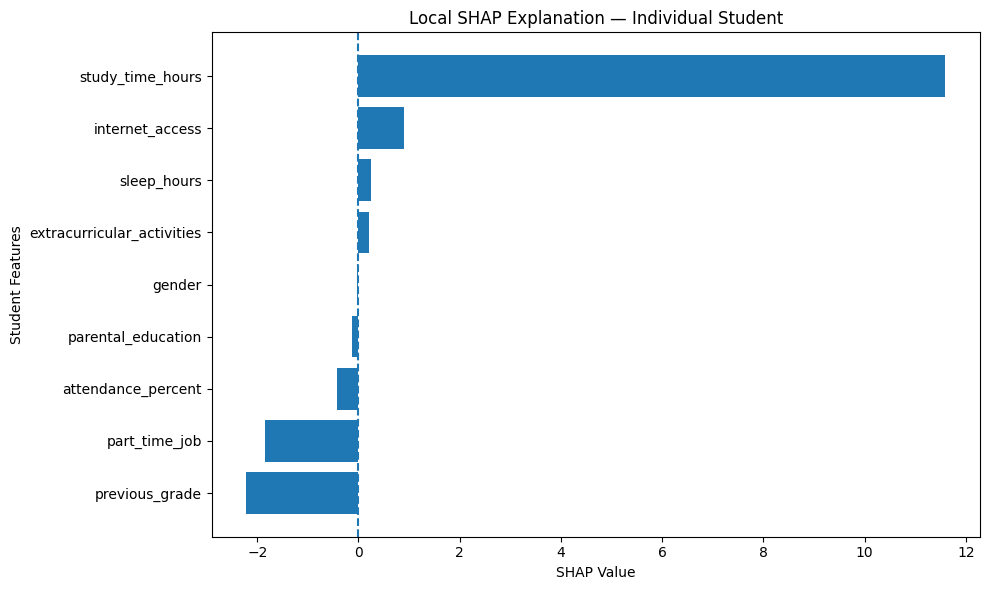

In [35]:
#  Local SHAP Feature Contribution Graph

local_plot_df = local_shap_df.sort_values(
    by="SHAP_Value"
)

plt.figure(figsize=(10, 6))

plt.barh(
    local_plot_df["Feature"],
    local_plot_df["SHAP_Value"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "SHAP Value"
)

plt.ylabel(
    "Student Features"
)

plt.title(
    "Local SHAP Explanation — Individual Student"
)

plt.tight_layout()

plt.show()

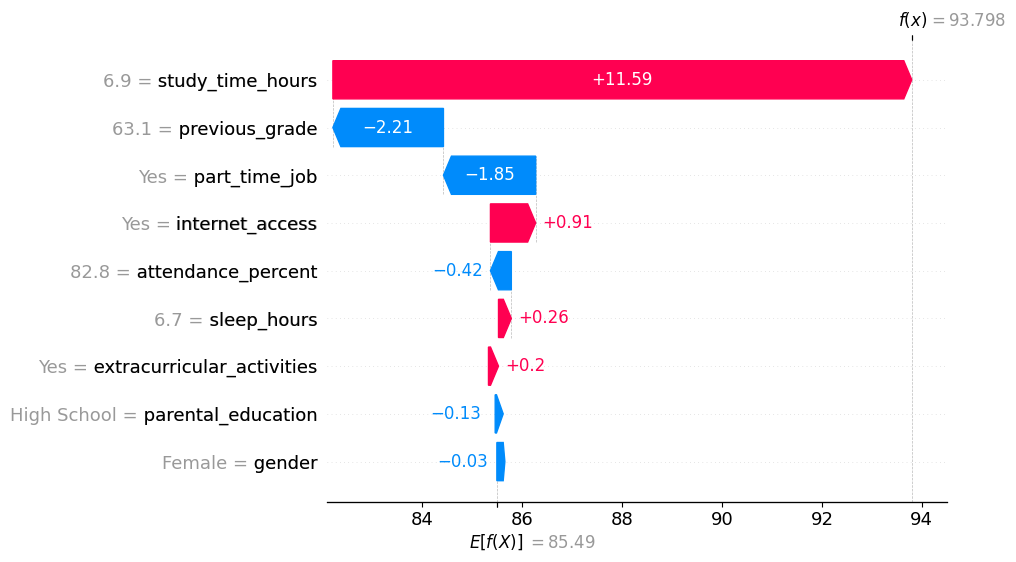

In [36]:
# SHAP Waterfall Explanation

student_explanation = shap.Explanation(
    values=student_shap_values,
    base_values=explainer.expected_value,
    data=student_data.iloc[0].values,
    feature_names=X_test.columns
)

shap.plots.waterfall(
    student_explanation,
    max_display=10
)

In [37]:
# Verify SHAP Prediction

expected_value = np.asarray(
    explainer.expected_value
).reshape(-1)[0]

shap_sum = (
    expected_value
    + student_shap_values.sum()
)

print("=" * 60)
print("SHAP PREDICTION VERIFICATION")
print("=" * 60)

print("\nSHAP expected value:")
print(round(expected_value, 4))

print("\nSum of SHAP contributions:")
print(round(student_shap_values.sum(), 4))

print("\nSHAP reconstructed prediction:")
print(round(shap_sum, 4))

print("\nActual TabPFN prediction:")
print(round(student_prediction, 4))

difference = abs(
    shap_sum - student_prediction
)

print("\nDifference:")
print(round(difference, 4))

SHAP PREDICTION VERIFICATION

SHAP expected value:
85.4903

Sum of SHAP contributions:
8.3078

SHAP reconstructed prediction:
93.7981

Actual TabPFN prediction:
93.7981

Difference:
0.0


In [38]:
# Human-Readable Local Explanation

print("=" * 70)
print("STUDENT PERFORMANCE EXPLANATION")
print("=" * 70)

print(
    f"\nStudent index: {student_index}"
)

print(
    f"Actual final exam score: "
    f"{student_actual_score:.2f}"
)

print(
    f"Predicted final exam score: "
    f"{student_prediction:.2f}"
)

print("\nMain factors influencing the prediction:")

for rank, row in enumerate(
    top_local_features.itertuples(index=False),
    start=1
):

    if row.SHAP_Value > 0:

        explanation = (
            f"contributed positively "
            f"(+{row.SHAP_Value:.2f})"
        )

    else:

        explanation = (
            f"contributed negatively "
            f"({row.SHAP_Value:.2f})"
        )

    print(
        f"{rank}. {row.Feature} "
        f"(value = {row.Feature_Value}) "
        f"→ {explanation}"
    )

STUDENT PERFORMANCE EXPLANATION

Student index: 436
Actual final exam score: 100.00
Predicted final exam score: 93.80

Main factors influencing the prediction:
1. study_time_hours (value = 6.9) → contributed positively (+11.59)
2. previous_grade (value = 63.1) → contributed negatively (-2.21)
3. part_time_job (value = Yes) → contributed negatively (-1.85)
4. internet_access (value = Yes) → contributed positively (+0.91)
5. attendance_percent (value = 82.8) → contributed negatively (-0.42)


In [39]:
# Save Local SHAP Results

LOCAL_SHAP_PATH = (
    XAI_RESULTS_PATH
    / "tabpfn_local_shap_student.csv"
)

local_shap_df.to_csv(
    LOCAL_SHAP_PATH,
    index=False
)

print("=" * 60)
print("LOCAL SHAP RESULTS SAVED")
print("=" * 60)

print("\nFile:")
print(LOCAL_SHAP_PATH)

LOCAL SHAP RESULTS SAVED

File:
d:\MCA Sem 3\RP\EduPredict-XAI\results\xai\tabpfn_local_shap_student.csv


In [40]:
# Save Student Explanation Summary

student_summary = pd.DataFrame({
    "Student_Index": [student_index],
    "Actual_Final_Exam_Score": [
        student_actual_score
    ],
    "Predicted_Final_Exam_Score": [
        student_prediction
    ],
    "Prediction_Error": [
        student_actual_score - student_prediction
    ]
})

STUDENT_SUMMARY_PATH = (
    XAI_RESULTS_PATH
    / "tabpfn_student_prediction_explanation.csv"
)

student_summary.to_csv(
    STUDENT_SUMMARY_PATH,
    index=False
)

print("=" * 60)
print("STUDENT SUMMARY SAVED")
print("=" * 60)

display(student_summary)

STUDENT SUMMARY SAVED


,Student_Index,Actual_Final_Exam_Score,Predicted_Final_Exam_Score,Prediction_Error
0,436,100.0,93.798073,6.201927


In [41]:
# Local XAI Completion Checkpoint

print("=" * 70)
print("STEP 18 — LOCAL SHAP ANALYSIS COMPLETED")
print("=" * 70)

print("\nMain Model:")
print("TabPFN")

print("\nTarget:")
print(TARGET)

print("\nXAI Technique:")
print("SHAP")

print("\nStudent analyzed:")
print(student_index)

print("\nActual score:")
print(round(student_actual_score, 2))

print("\nPredicted score:")
print(round(student_prediction, 2))

print("\nTop influencing features:")

for rank, feature in enumerate(
    top_local_features["Feature"],
    start=1
):
    print(f"{rank}. {feature}")

print("\nFiles created:")
print("✓ tabpfn_local_shap_student.csv")
print("✓ tabpfn_student_prediction_explanation.csv")

print("\n" + "=" * 70)
print("STEP 18 COMPLETED SUCCESSFULLY!")
print("=" * 70)

STEP 18 — LOCAL SHAP ANALYSIS COMPLETED

Main Model:
TabPFN

Target:
final_exam_score

XAI Technique:
SHAP

Student analyzed:
436

Actual score:
100.0

Predicted score:
93.8

Top influencing features:
1. study_time_hours
2. previous_grade
3. part_time_job
4. internet_access
5. attendance_percent

Files created:
✓ tabpfn_local_shap_student.csv
✓ tabpfn_student_prediction_explanation.csv

STEP 18 COMPLETED SUCCESSFULLY!
